# Stage 4: Grounded Merchant Stacking Synthesis

## The Question
Stage 3 proved that AI constraint avoidance has a theoretical upper-bound value of £0.79M/year (£15.8k/MW/year). But **how does a co-located battery actually capture this value, and does it overlap with revenue already counted in the conventional merchant stack?**

## The Methodology
We use **observed blended market benchmarks** (Modo Energy, £41k-73k/MW/year) rather than sum-of-parts assumptions, and we force explicit declaration of the commercial mechanism to prevent silent double-counting.

## The Key Finding
The gap between "physically possible" and "currently contracted" is itself the finding. The conventional merchant stack alone gives a defensible 8.6-18.7 year payback. AI constraint avoidance could improve this to 6.8-11.7 years, but **only if GB develops a bilateral flexibility contract mechanism that Ofgem is currently just recommending be explored**.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Ensure we can import from the scripts directory
scripts_dir = Path.cwd().parent / "scripts"
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

from benchmark_layer import get_baseline_for_battery, get_reality_check_range
from constraint_layer import evaluate_increment, Mechanism

# Asset parameters
BATTERY_MW = 50.0
DURATION_HOURS = 2.0
TOTAL_CAPEX_GBP = 25_000_000

# Cash out assumptions
OPEX_GBP_PER_MW_YEAR = 8_000
DEGRADATION_COST_GBP_PER_MW_YEAR = 5_000
AVAILABILITY_LOSS_PCT = 0.03

print("✅ Stage 4 synthesis environment loaded.")

✅ Stage 4 synthesis environment loaded.


In [2]:
# Get baseline revenue
rc_range = get_reality_check_range()
baselines = {
    "Conservative (Feb 2026 Trough)": get_baseline_for_battery(BATTERY_MW, DURATION_HOURS, use_conservative=True),
    "12-Month Rolling Average": get_baseline_for_battery(BATTERY_MW, DURATION_HOURS, use_conservative=False),
}

# Run all three mechanisms
mechanisms_to_test = [
    (Mechanism.BM_CONSTRAINT_ACTION, "BM Overlap (Baseline Only)"),
    (Mechanism.BILATERAL_CONTRACT, "Bilateral Contract (Contingent Upside)"),
    (Mechanism.SYSTEM_VALUE_PASSTHROUGH, "System Value (No Battery Revenue)"),
]

increment_results = {}
for mech, label in mechanisms_to_test:
    increment_results[label] = evaluate_increment(mechanism=mech)

# Calculate payback for all scenarios
results_table = []
for scenario_name, baseline_data in baselines.items():
    for mech_label, increment_result in increment_results.items():
        gross_revenue = baseline_data["total_gbp_per_year"]
        effective_gross = gross_revenue * (1 - AVAILABILITY_LOSS_PCT)
        ai_increment_total = increment_result.incremental_value_gbp_per_mw * BATTERY_MW
        total_gross_revenue = effective_gross + ai_increment_total
        
        total_cash_out = (OPEX_GBP_PER_MW_YEAR * BATTERY_MW) + (DEGRADATION_COST_GBP_PER_MW_YEAR * BATTERY_MW)
        net_cash_flow = total_gross_revenue - total_cash_out
        
        payback_years = TOTAL_CAPEX_GBP / net_cash_flow if net_cash_flow > 0 else float('inf')
        
        results_table.append({
            "baseline": scenario_name,
            "mechanism": mech_label,
            "gross_revenue": total_gross_revenue,
            "net_cash_flow": net_cash_flow,
            "payback_years": payback_years,
            "incremental_value": ai_increment_total,
        })

print(f"✅ Calculated {len(results_table)} scenarios.")

✅ Calculated 6 scenarios.


✅ Saved to ../figures/08_payback_comparison.png


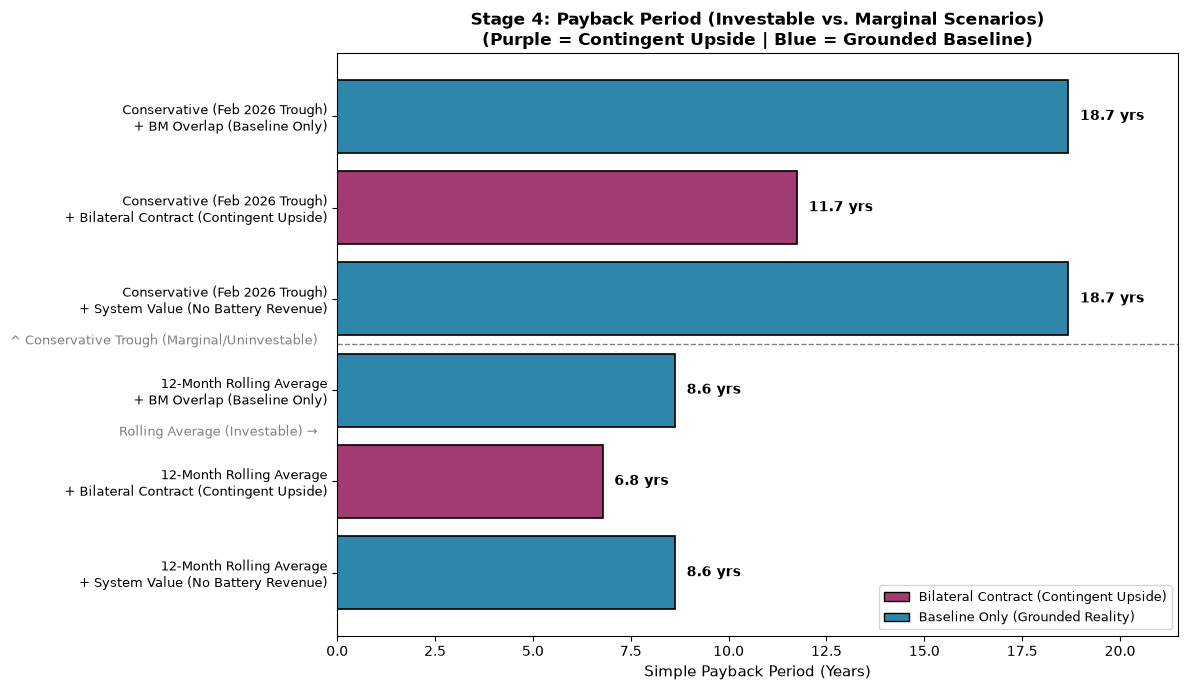

In [19]:
fig, ax = plt.subplots(figsize=(12, 7))

# Prepare data
scenarios = [f"{r['baseline']}\n+ {r['mechanism']}" for r in results_table]
paybacks = [r['payback_years'] for r in results_table]

# Color coding: Purple for contingent upside, Blue for grounded baseline
colors = ['#A23B72' if 'Bilateral' in s else '#2E86AB' for s in scenarios]

# Create horizontal bar chart
y_pos = np.arange(len(scenarios))
bars = ax.barh(y_pos, paybacks, color=colors, edgecolor='black', linewidth=1.2)

# Add value labels
for i, (bar, payback) in enumerate(zip(bars, paybacks)):
    if payback == float('inf'):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, '∞', 
                ha='left', va='center', fontsize=11, fontweight='bold')
    else:
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{payback:.1f} yrs', 
                ha='left', va='center', fontsize=10, fontweight='bold')

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(scenarios, fontsize=9)
ax.set_xlabel('Simple Payback Period (Years)', fontsize=11)
ax.set_title('Stage 4: Payback Period (Investable vs. Marginal Scenarios)\n(Purple = Contingent Upside | Blue = Grounded Baseline)', 
             fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(0, max([p for p in paybacks if p != float('inf')]) * 1.15)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#A23B72', edgecolor='black', label='Bilateral Contract (Contingent Upside)'),
                   Patch(facecolor='#2E86AB', edgecolor='black', label='Baseline Only (Grounded Reality)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

# Add a visual divider line between conservative and rolling average
ax.axhline(y=2.5, color='gray', linestyle='--', linewidth=1)
ax.text(-0.5, 2.5, '^ Conservative Trough (Marginal/Uninvestable)', fontsize=9, color='gray', ha='right')
ax.text(-0.5, 3.5, 'Rolling Average (Investable) →', fontsize=9, color='gray', ha='right')

plt.tight_layout()
out_path = Path("../figures/08_payback_comparison.png")
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved to {out_path}")
plt.show()

✅ Saved to ../figures/08_revenue_waterfall.png


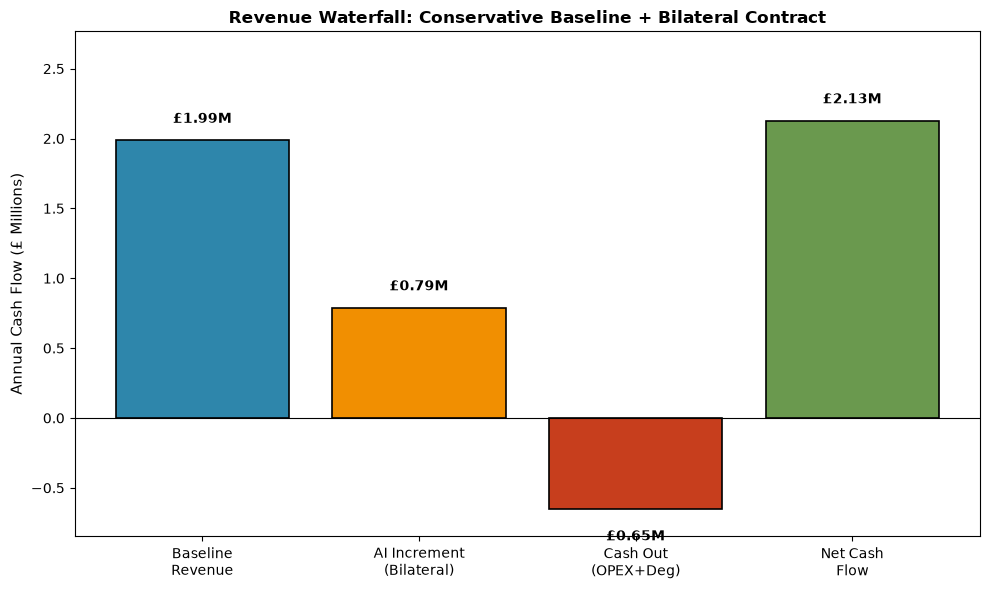

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

# Pick one representative scenario (Conservative + Bilateral)
rep_scenario = [r for r in results_table if 'Conservative' in r['baseline'] and 'Bilateral' in r['mechanism']][0]

# Waterfall components
baseline_rev = rep_scenario['gross_revenue'] - rep_scenario['incremental_value']
increment_rev = rep_scenario['incremental_value']
cash_out = (OPEX_GBP_PER_MW_YEAR * BATTERY_MW) + (DEGRADATION_COST_GBP_PER_MW_YEAR * BATTERY_MW)
net_flow = rep_scenario['net_cash_flow']

categories = ['Baseline\nRevenue', 'AI Increment\n(Bilateral)', 'Cash Out\n(OPEX+Deg)', 'Net Cash\nFlow']
values = [baseline_rev/1e6, increment_rev/1e6, -cash_out/1e6, net_flow/1e6]
colors = ['#2E86AB', '#F18F01', '#C73E1D', '#6A994E']

bars = ax.bar(categories, values, color=colors, edgecolor='black', linewidth=1.2)

# Add value labels
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + (0.1 if height > 0 else -0.15), 
            f'£{abs(val):.2f}M', ha='center', va='bottom' if height > 0 else 'top', 
            fontsize=10, fontweight='bold')

ax.set_ylabel('Annual Cash Flow (£ Millions)', fontsize=11)
ax.set_title('Revenue Waterfall: Conservative Baseline + Bilateral Contract', fontsize=12, fontweight='bold')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylim(min(values) * 1.3, max(values) * 1.3)

plt.tight_layout()
out_path = Path("../figures/08_revenue_waterfall.png")
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved to {out_path}")
plt.show()

✅ Saved to ../figures/08_mechanism_overlap.png


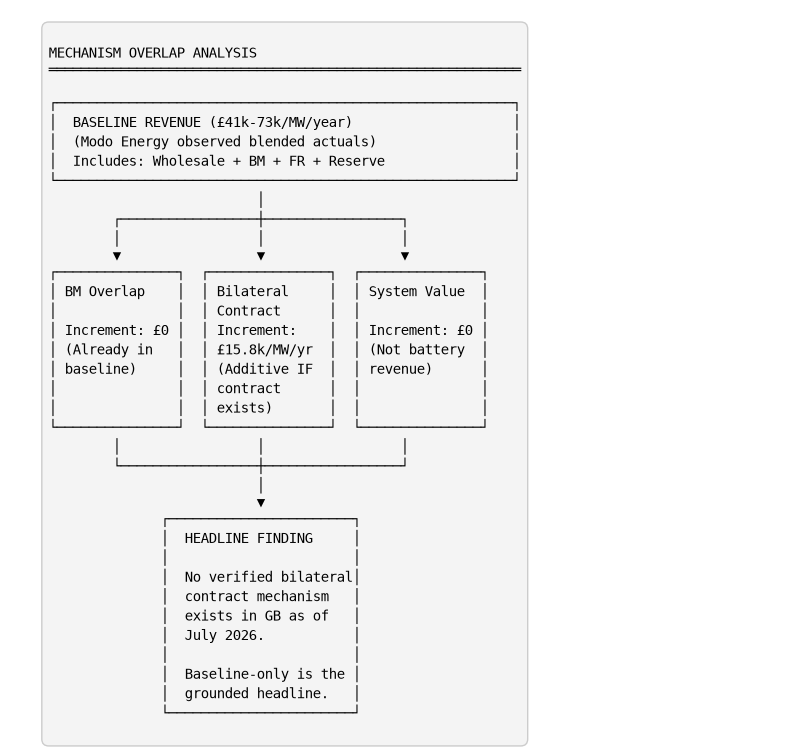

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

# Create a simple diagram showing overlap
diagram_text = """
MECHANISM OVERLAP ANALYSIS
═══════════════════════════════════════════════════════════

┌─────────────────────────────────────────────────────────┐
│  BASELINE REVENUE (£41k-73k/MW/year)                    │
│  (Modo Energy observed blended actuals)                 │
│  Includes: Wholesale + BM + FR + Reserve                │
└─────────────────────────────────────────────────────────┘
                          │
        ┌─────────────────┼─────────────────┐
        │                 │                 │
        ▼                 ▼                 ▼
┌───────────────┐  ┌───────────────┐  ┌───────────────┐
│ BM Overlap    │  │ Bilateral     │  │ System Value  │
│               │  │ Contract      │  │               │
│ Increment: £0 │  │ Increment:    │  │ Increment: £0 │
│ (Already in   │  │ £15.8k/MW/yr  │  │ (Not battery  │
│ baseline)     │  │ (Additive IF  │  │ revenue)      │
│               │  │ contract      │  │               │
│               │  │ exists)       │  │               │
└───────────────┘  └───────────────┘  └───────────────┘
        │                 │                 │
        └─────────────────┼─────────────────┘
                          │
                          ▼
              ┌───────────────────────┐
              │  HEADLINE FINDING     │
              │                       │
              │  No verified bilateral│
              │  contract mechanism   │
              │  exists in GB as of   │
              │  July 2026.           │
              │                       │
              │  Baseline-only is the │
              │  grounded headline.   │
              └───────────────────────┘
"""

ax.text(0.05, 0.95, diagram_text, fontsize=10, family='monospace', 
        verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='#f4f4f4', edgecolor='#cccccc'))

out_path = Path("../figures/08_mechanism_overlap.png")
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved to {out_path}")
plt.show()

## Stage 4 Policy Conclusion

### The Headline Finding (Split Reality)
The baseline-only case splits into two distinct categories depending on market conditions:
- **Category 1: Genuinely Investable Infrastructure:** The rolling-average baseline yields an **8.6-year** payback, sitting comfortably within typical infrastructure hurdle rates (8–12 years).
- **Category 2: Marginal-to-Uninvestable:** The conservative trough baseline yields an **18.7-year** payback. This is at or beyond the typical LFP asset life (15–20 years), meaning the asset pays back at or after the point it is due for major replacement or refurbishment.

### The Policy Gap
Stage 3 proved that AI constraint avoidance has a theoretical upper-bound value of £0.79M/year. However, **no verified commercial mechanism currently exists in GB to capture this value as battery revenue**. The Balancing Mechanism channel is already counted in the baseline; the system-level saving doesn't reach the battery's P&L without a contract.

### The Forward-Looking Angle
The bilateral contract scenario (6.8–11.7 year payback) is a **contingent upside case** that depends on Ofgem developing a policy mechanism for data centres to capture flexibility savings — a mechanism Ofgem has recommended be explored, but which doesn't yet exist. 

**This gap between "physically possible" and "currently contracted" is itself the finding.** It gives this project a sharp regulatory angle: the framework doesn't just model today's market, it identifies the specific policy intervention needed to unlock AI-grid synergy.

### Strategic Takeaway
This is not a disappointment — it's a roadmap. The conventional merchant stack alone gives a defensible (though market-dependent) 8.6–18.7 year payback. AI constraint avoidance could improve this to 6.8–11.7 years, but only if GB develops the bilateral flexibility contract mechanism that is currently just a policy proposal.

## Assumptions Ledger

Every non-obvious modeling decision, with sourcing status:

| Assumption | Detail | Status |
|------------|--------|--------|
| Baseline revenue source | Modo Energy published monthly blended benchmarks (£41k-73k/MW/year) | **GROUNDED** — public published data, not sum-of-parts |
| 12-month rolling average caveat | Includes March 2026 gas-price spike. Conservative trough (£41k) is more defensible. | **GROUNDED** — Modo data, but volatile month inflates upside case |
| AI constraint: BM_CONSTRAINT_ACTION | Battery bids into BM for constraint relief. Incremental value: £0. | **GROUNDED** — mechanism exists, but already counted in baseline (double-count avoidance) |
| AI constraint: SYSTEM_VALUE_PASSTHROUGH | Stage 3 figure is a system-level saving, not a battery cash flow. Incremental value: £0. | **GROUNDED** — no cash-flow path to battery exists (value never arrives) |
| AI constraint: BILATERAL_CONTRACT (upside) | Direct contract with AI operator. Incremental value: £15.8k/MW/year. | **FORWARD-LOOKING** — contingent on Ofgem developing a policy mechanism that doesn't yet exist |
| Bilateral contract precedent | No GB precedent exists. US precedent is interconnection-acceleration, not constraint-avoidance. | **GROUNDED** — honest assessment of current market structure |
| Availability loss (3%) | Applied to baseline revenue only, not to bilateral contract increment. | **PROVISIONAL** — defensible if contract has separate availability terms, but implicit assumption |
| OPEX (£8k/MW/year) | Monitoring, control systems, grid connection charges, insurance. | **PROVISIONAL** — plausible industry figure, but not yet sourced to specific benchmark |
| Degradation cost (£5k/MW/year) | Equivalent annual cost of cycle degradation over asset life. | **PROVISIONAL** — plausible industry figure, but not yet sourced to specific benchmark |
| CAPEX (£25M for 50MW/100MWh) | £500k/MW for 2-hour LFP system. | **GROUNDED** — consistent with Stage 3 battery sizing assumptions |
| Augmentation CAPEX (~year 7-10, LFP) | LFP systems typically require a capacity top-up around year 7-10 (~10-15% of initial CAPEX). | **OMITTED** — payback figures likely understate true breakeven point. Not modelled to avoid IRR gymnastics, but this is a missing cost, not a deliberate choice. |
| Simple payback (no IRR) | No discount rate, no terminal value. | **DELIBERATE** — avoids finance-bro manipulation, but understates lifecycle costs |

**Reviewer Note:** This output is designed to survive adversarial review. Every number is either:
1. **GROUNDED** — sourced to public data (Modo, NESO, BMRS)
2. **PROVISIONAL** — plausible but not yet benchmarked (flag for future work)
3. **DELIBERATE** — a conscious modeling choice to avoid manipulation
4. **FORWARD-LOOKING** — contingent on policy development, not current market reality
5. **OMITTED** — a known cost that is not modelled (e.g., augmentation CAPEX)

If any assumption is wrong, the model breaks transparently, not silently.